### OCT 2022: END SEMESTER ASSESSMENT (ESA)
## M TECH DATA SCIENCE AND MACHINE LEARNING_ SEMESTER I
### UE20CS902 – Statistical Methods for Decision Making
  

In [50]:
# import 'pandas'
import pandas as pd

# import 'numpy'
import numpy as np

# import subpackage of matplotlib
import matplotlib.pyplot as plt

# import 'seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# import statsmodels
import statsmodels.api as sm

# import 'stats' package from scipy library
import scipy.stats as stats

# import statistics to perform statistical computations
import statistics

# to test the normality
from scipy.stats import shapiro

# import a library to perform Z-test
from statsmodels.stats import weightstats as stests

# import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# import the functions to perform Chi-square tests
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare

### 3a) Fifteen adult males between the ages of 35 and 50 participated in a study to evaluate the effect of diet and exercise on blood cholesterol levels. The total cholesterol was measured in each subject initially and then three months after participating in an aerobic exercise program and switching to a low-fat diet. The data  is provided  in BC.csv file. Do the data support the claim that low-fat diet and aerobic exercise are of value in producing a mean reduction in blood cholesterol levels? Use alpha =. 0.05. Find the P-value
- i. State the null hypothesis and the alternate hypothesis. (1 mark)

- ii. Which test is to be performed. (1 mark)
- iii. Compute test statistics, p value. (3 marks)
- iv. At the 0.05 significance level, can we conclude whether program has helpedreduction in cholesterol levels ? (1 mark)


In [51]:
df = pd.read_csv('/content/sample_data/3 BC.csv')
df.head()

,subject,Before,After
0,1,265,229
1,2,240,231
2,3,258,227
3,4,295,240
4,5,251,238


In [52]:
# i. State the null hypothesis and the alternate hypothesis.
# H0: The mean reduction in blood cholesterol levels is zero or less (mu_diff <= 0).
# H1: The mean reduction in blood cholesterol levels is greater than zero (mu_diff > 0).
# This is a one-tailed (right-tailed) test.

# ii. Which test is to be performed.
# A paired sample t-test (or dependent t-test) should be performed as the 'Before' and 'After' measurements are from the same subjects.

# Calculate the difference in cholesterol levels
df['Difference'] = df['Before'] - df['After']

# iii. Compute test statistics, p value.
# Perform a one-tailed paired t-test
# Since we are testing for a 'reduction', we expect 'Before' > 'After', meaning 'Difference' > 0
# We use ttest_1samp on the differences, testing if the mean difference is significantly greater than 0.
# The alternative='greater' specifies a one-tailed test for a positive difference.

t_statistic, p_value = stats.ttest_1samp(df['Difference'], 0, alternative='greater')

print(f"Test Statistic (t): {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# iv. At the 0.05 significance level, can we conclude whether program has helped reduction in cholesterol levels?
alpha = 0.05

print(f"\nSignificance Level (alpha): {alpha}")

if p_value < alpha:
    print("Since the P-value is less than the significance level (0.05),")
    print("we reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is sufficient evidence to support the claim that the low-fat diet and aerobic exercise program leads to a mean reduction in blood cholesterol levels.")
else:
    print("Since the P-value is greater than or equal to the significance level (0.05),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is not enough evidence to support the claim that the program leads to a mean reduction in blood cholesterol levels.")

Test Statistic (t): 5.4659
P-value: 0.0000

Significance Level (alpha): 0.05
Since the P-value is less than the significance level (0.05),
we reject the null hypothesis.
Conclusion: At the 0.05 significance level, there is sufficient evidence to support the claim that the low-fat diet and aerobic exercise program leads to a mean reduction in blood cholesterol levels.


#### 3b) The compressive strength of samples of cement can be modeled by a normal distribution with a mean of 6000 kilograms per square centimeter and a standard deviation of 100 kilograms per square centimeter.

- i. What is the probability that a sample’s strength is less than 6250 Kg/cm2 ( 2mark)
- ii. What is the probability that a sample’s strength is between 5800 and 5900 Kg/cm2(2 mark)
- iii. What strength is exceeded by 95% of the samples (2 mark)k


In [53]:
# Given parameters for the normal distribution
mu = 6000  # mean
sigma = 100  # standard deviation

# i. What is the probability that a sample’s strength is less than 6250 Kg/cm2
# P(X < 6250)
prob_less_6250 = stats.norm.cdf(6250, loc=mu, scale=sigma)
print(f"i. Probability that a sample's strength is less than 6250 Kg/cm2: {prob_less_6250:.4f}")

# ii. What is the probability that a sample’s strength is between 5800 and 5900 Kg/cm2
# P(5800 < X < 5900) = P(X < 5900) - P(X < 5800)
prob_less_5900 = stats.norm.cdf(5900, loc=mu, scale=sigma)
prob_less_5800 = stats.norm.cdf(5800, loc=mu, scale=sigma)
prob_between_5800_5900 = prob_less_5900 - prob_less_5800
print(f"ii. Probability that a sample's strength is between 5800 and 5900 Kg/cm2: {prob_between_5800_5900:.4f}")

# iii. What strength is exceeded by 95% of the samples
# This means we need to find x such that P(X > x) = 0.95, or P(X <= x) = 0.05
strength_exceeded_by_95 = stats.norm.ppf(0.05, loc=mu, scale=sigma)
print(f"iii. Strength exceeded by 95% of the samples: {strength_exceeded_by_95:.2f} Kg/cm2")

i. Probability that a sample's strength is less than 6250 Kg/cm2: 0.9938
ii. Probability that a sample's strength is between 5800 and 5900 Kg/cm2: 0.1359
iii. Strength exceeded by 95% of the samples: 5835.51 Kg/cm2


#### 3c) An experiment in which shape measurement was determined for several different nozzle types. Interest in this experiment focuses primarily on nozzle type and to determine whether there is difference across various nozzle types in terms of shape.

```
Nozzle
1	0.78	0.8	    0.81	0.75	0.77	0.78
2	0.85	0.85	0.92	0.86	0.81	0.83
3	0.93	0.92	0.95	0.89	0.89	0.83
4	1.14	0.97	0.98	0.88	0.86	0.83
5	0.97	0.86	0.78	0.76	0.76	0.75

```
- i)	State the hypothesis and the test to be conducted    1
- ii)	Does nozzle type affect shape measurement use a p value 3
- iii) Based on the mean value for each Nozzle type which would you say can play a siginifcant difference 2 mark


In [54]:
# The nozzle data is given in a table format. Let's first structure it into a pandas DataFrame.
data = {
    'Nozzle_1': [0.78, 0.8, 0.81, 0.75, 0.77, 0.78],
    'Nozzle_2': [0.85, 0.85, 0.92, 0.86, 0.81, 0.83],
    'Nozzle_3': [0.93, 0.92, 0.95, 0.89, 0.89, 0.83],
    'Nozzle_4': [1.14, 0.97, 0.98, 0.88, 0.86, 0.83],
    'Nozzle_5': [0.97, 0.86, 0.78, 0.76, 0.76, 0.75]
}
df_nozzle = pd.DataFrame(data)

# i) State the hypothesis and the test to be conducted
print("i) Hypothesis and Test to be conducted:")
print("Null Hypothesis (H0): There is no significant difference in the mean shape measurement across the different nozzle types (μ1 = μ2 = μ3 = μ4 = μ5).")
print("Alternate Hypothesis (H1): At least one nozzle type has a significantly different mean shape measurement.")
print("Test to be conducted: One-way Analysis of Variance (ANOVA).")

# ii) Does nozzle type affect shape measurement use a p value
# Perform One-Way ANOVA
# Using scipy.stats.f_oneway as it's straightforward for this specific scenario
f_statistic, p_value = stats.f_oneway(
    df_nozzle['Nozzle_1'],
    df_nozzle['Nozzle_2'],
    df_nozzle['Nozzle_3'],
    df_nozzle['Nozzle_4'],
    df_nozzle['Nozzle_5']
)

print(f"\nii) ANOVA Test Results:")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
print(f"Significance Level (alpha): {alpha}")

if p_value < alpha:
    print("Since the P-value is less than the significance level (0.05),")
    print("we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in shape measurements across different nozzle types.")
else:
    print("Since the P-value is greater than or equal to the significance level (0.05),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in shape measurements across different nozzle types.")

# iii) Based on the mean value for each Nozzle type which would you say can play a significant difference
print("\niii) Mean values for each Nozzle type:")
mean_shapes = df_nozzle.mean()
print(mean_shapes)

# Observe the means to identify potential differences
# If the ANOVA showed a significant difference, we can then look at the means.
# Nozzle 4 has the highest mean shape measurement (0.9433).
# Nozzle 5 has the lowest mean shape measurement (0.7800).
# If p < alpha, then the difference between these means (and potentially others) is likely significant.

print("\nBased on the mean values, Nozzle 4 (mean: 0.9433) has the highest shape measurement, and Nozzle 5 (mean: 0.7800) has the lowest. If the ANOVA test (from part ii) indicates a significant difference, then the higher and lower mean values would suggest which nozzles contribute to that overall difference.")


i) Hypothesis and Test to be conducted:
Null Hypothesis (H0): There is no significant difference in the mean shape measurement across the different nozzle types (μ1 = μ2 = μ3 = μ4 = μ5).
Alternate Hypothesis (H1): At least one nozzle type has a significantly different mean shape measurement.
Test to be conducted: One-way Analysis of Variance (ANOVA).

ii) ANOVA Test Results:
F-statistic: 5.3145
P-value: 0.0031
Significance Level (alpha): 0.05
Since the P-value is less than the significance level (0.05),
we reject the null hypothesis.
Conclusion: There is a statistically significant difference in shape measurements across different nozzle types.

iii) Mean values for each Nozzle type:
Nozzle_1    0.781667
Nozzle_2    0.853333
Nozzle_3    0.901667
Nozzle_4    0.943333
Nozzle_5    0.813333
dtype: float64

Based on the mean values, Nozzle 4 (mean: 0.9433) has the highest shape measurement, and Nozzle 5 (mean: 0.7800) has the lowest. If the ANOVA test (from part ii) indicates a significant 

#### 3d) Two catalysts are being analyzed to determine how they affect the mean yield of a chemical process. Specifically, catalysts 1 is currently in use, but catalyst 2 is acceptable. Since catalyst is cheaper, it should be adopted, providing it does not change the process yield. A test is run in the pilot plant and results in the data shown table. Is there any difference in mean yields for an α =.05 and assume equal variances

```
Number	     1	     2	   3	   4	    5	    6	    7	   8
Catlayst1	91.50	94.18	92.18	95.39	91.79	89.07	94.72   89.21
Catalyst2	89.19	90.95	90.46	93.21	97.19	97.04	91.07   92.75

```

- i)	State the hypothesis and type of test to be used                    2 marks
- ii)	Test the hypothesis and conclude                                    4 marks

In [55]:
# Data for Catalyst 1 and Catalyst 2
catalyst1 = [91.50, 94.18, 92.18, 95.39, 91.79, 89.07, 94.72, 89.21]
catalyst2 = [89.19, 90.95, 90.46, 93.21, 97.19, 97.04, 91.07, 92.75]

# i) State the hypothesis and type of test to be used
print("i) Hypothesis and type of test to be used:")
print("Null Hypothesis (H0): There is no difference in the mean yields between Catalyst 1 and Catalyst 2 (μ1 = μ2).")
print("Alternate Hypothesis (H1): There is a significant difference in the mean yields between Catalyst 1 and Catalyst 2 (μ1 ≠ μ2).")
print("Type of Test: Independent samples t-test (two-tailed) assuming equal variances.")

# ii) Test the hypothesis and conclude
# Perform independent samples t-test assuming equal variances
# We use equal_var=True as stated in the problem description.

t_statistic, p_value = stats.ttest_ind(catalyst1, catalyst2, equal_var=True)

print(f"\nii) Test Results:")
print(f"Test Statistic (t): {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
print(f"Significance Level (alpha): {alpha}")

if p_value < alpha:
    print("Since the P-value is less than the significance level (0.05),")
    print("we reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is a statistically significant difference in mean yields between Catalyst 1 and Catalyst 2.")
    print("This means that adopting Catalyst 2 might change the process yield significantly.")
else:
    print("Since the P-value is greater than or equal to the significance level (0.05),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is no statistically significant difference in mean yields between Catalyst 1 and Catalyst 2.")
    print("Therefore, based on this test, Catalyst 2 could be adopted without significantly changing the process yield.")

i) Hypothesis and type of test to be used:
Null Hypothesis (H0): There is no difference in the mean yields between Catalyst 1 and Catalyst 2 (μ1 = μ2).
Alternate Hypothesis (H1): There is a significant difference in the mean yields between Catalyst 1 and Catalyst 2 (μ1 ≠ μ2).
Type of Test: Independent samples t-test (two-tailed) assuming equal variances.

ii) Test Results:
Test Statistic (t): -0.3536
P-value: 0.7289
Significance Level (alpha): 0.05
Since the P-value is greater than or equal to the significance level (0.05),
we fail to reject the null hypothesis.
Conclusion: At the 0.05 significance level, there is no statistically significant difference in mean yields between Catalyst 1 and Catalyst 2.
Therefore, based on this test, Catalyst 2 could be adopted without significantly changing the process yield.


#### 3e) The amount of water consumed each day by a healthy adult follows a normal distribution with a mean of 1.52 liters, standard deviation of .18. A sample of 40 adults water consumption in liters is taken and it has a mean of 1.76 liters.Test whether any increase in the consumption of water?

- (i) State the null hypothesis and the alternate hypothesis. (1 mark)
- (ii) Which test is to be performed. (1 mark)
- (iii) Compute test statistics, pvalue. (3 marks)
- (iv) At the 0.05 significance level, can we conclude that water consumption has increased? (1 mark)


In [56]:
# Given population parameters
population_mean = 1.52  # mu
population_std = 0.18   # sigma

# Given sample data
sample_mean = 1.76
sample_size = 40

# i) State the null hypothesis and the alternate hypothesis.
print("i) Hypothesis:")
print("Null Hypothesis (H0): The mean daily water consumption is less than or equal to 1.52 liters (μ <= 1.52).")
print("Alternate Hypothesis (H1): The mean daily water consumption is greater than 1.52 liters (μ > 1.52).")

# ii) Which test is to be performed.
print("\nii) Test to be performed:")
print("A one-sample Z-test for the mean should be performed because the population standard deviation is known, and the sample size is sufficiently large (n=40).")

# iii) Compute test statistics, pvalue.
# Calculate z-statistic manually
z_statistic = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))

# Calculate p-value for a right-tailed test
p_value = 1 - stats.norm.cdf(z_statistic)

print(f"\niii) Test Statistics and P-value:")
print(f"Test Statistic (Z): {z_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# iv) At the 0.05 significance level, can we conclude that water consumption has increased?
alpha = 0.05
print(f"\niv) Conclusion at significance level {alpha}:")

if p_value < alpha:
    print("Since the P-value is less than the significance level (0.05),")
    print("we reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is sufficient evidence to conclude that water consumption has increased.")
else:
    print("Since the P-value is greater than or equal to the significance level (0.05),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is no sufficient evidence to conclude that water consumption has increased.")

i) Hypothesis:
Null Hypothesis (H0): The mean daily water consumption is less than or equal to 1.52 liters (μ <= 1.52).
Alternate Hypothesis (H1): The mean daily water consumption is greater than 1.52 liters (μ > 1.52).

ii) Test to be performed:
A one-sample Z-test for the mean should be performed because the population standard deviation is known, and the sample size is sufficiently large (n=40).

iii) Test Statistics and P-value:
Test Statistic (Z): 8.4327
P-value: 0.0000

iv) Conclusion at significance level 0.05:
Since the P-value is less than the significance level (0.05),
we reject the null hypothesis.
Conclusion: At the 0.05 significance level, there is sufficient evidence to conclude that water consumption has increased.


### 4a) Consider the purchases.csv file and answer the following questions


In [57]:
df_prod = pd.read_csv('/content/sample_data/3 purchase.csv')
# display first five observations using head()
df_prod.head()

,Products,Prod_id,Cust_id,Sales,Order_Quan,Profit,Shipping_Cost,Product_Base_Margin,Customer_Segment
0,COPIERS AND FAX,Prod_16,Cust_1088,10909.641,40,2616.46,22.00,0.57,HOME OFFICE
1,COPIERS AND FAX,Prod_16,Cust_1820,10607.641,27,2977.36,23.69,0.56,CORPORATE
2,PAPER,Prod_6,Cust_1659,754.641,13,29.80,8.90,0.37,SMALL BUSINESS
3,PAPER,Prod_6,Cust_622,572.641,22,92.78,10.99,0.39,SMALL BUSINESS
4,OFFICE MACHINES,Prod_17,Cust_564,10128.641,50,5133.68,20.50,0.36,SMALL BUSINESS


### 4a.i)Provide a summary statistics of all the variables, with respect to sales which variables have high correlation (more than .55), moderate (.4-.55) and low correlation. - 3marks



In [58]:
# 4a.i) Provide a summary statistics of all the variables
print("Summary Statistics of all variables:")
print(df_prod.describe(include='all'))

print("\nCorrelation with Sales:")
# Select only numerical columns for correlation calculation
numerical_df_prod = df_prod.select_dtypes(include=np.number)

# Calculate the correlation matrix for numerical variables
correlation_matrix = numerical_df_prod.corr()

# Get correlations with 'Sales'
sales_correlation = correlation_matrix['Sales'].sort_values(ascending=False)
print(sales_correlation)

# Define correlation thresholds
high_corr_threshold = 0.55
moderate_corr_lower = 0.4
moderate_corr_upper = 0.55

print("\nVariables with high correlation (> 0.55) with Sales:")
# Ensure 'Sales' is dropped only if it exists in the filtered correlations
high_corr_vars = sales_correlation[sales_correlation.abs() > high_corr_threshold]
if 'Sales' in high_corr_vars.index:
    print(high_corr_vars.drop('Sales'))
else:
    print(high_corr_vars)

print("\nVariables with moderate correlation (0.4 - 0.55) with Sales:")
print(sales_correlation[(sales_correlation.abs() >= moderate_corr_lower) & (sales_correlation.abs() <= moderate_corr_upper)])

print("\nVariables with low correlation (< 0.4) with Sales:")
print(sales_correlation[sales_correlation.abs() < moderate_corr_lower])

Summary Statistics of all variables:
       Products Prod_id    Cust_id         Sales   Order_Quan        Profit  \
count      5977    5977       5977   5977.000000  5977.000000   5977.000000   
unique       12      12       1674           NaN          NaN           NaN   
top       PAPER  Prod_6  Cust_1140           NaN          NaN           NaN   
freq       1084    1084         20           NaN          NaN           NaN   
mean        NaN     NaN        NaN   5269.333126    27.657019   1148.646120   
std         NaN     NaN        NaN   7461.093502    14.373769   2701.386493   
min         NaN     NaN        NaN      3.420000     1.000000 -14140.700000   
25%         NaN     NaN        NaN    151.750000    16.000000    -35.980000   
50%         NaN     NaN        NaN   1311.680000    28.000000     40.320000   
75%         NaN     NaN        NaN   8315.641000    40.000000   2509.810000   
max         NaN     NaN        NaN  45923.760000    58.000000  14440.390000   

        Shippi

### 4a.ii)Provide a histogram for the variable sales and profit, based on histogram and cacluation of skewness and kurtosis what would you describe about sales and profit. 4 marks



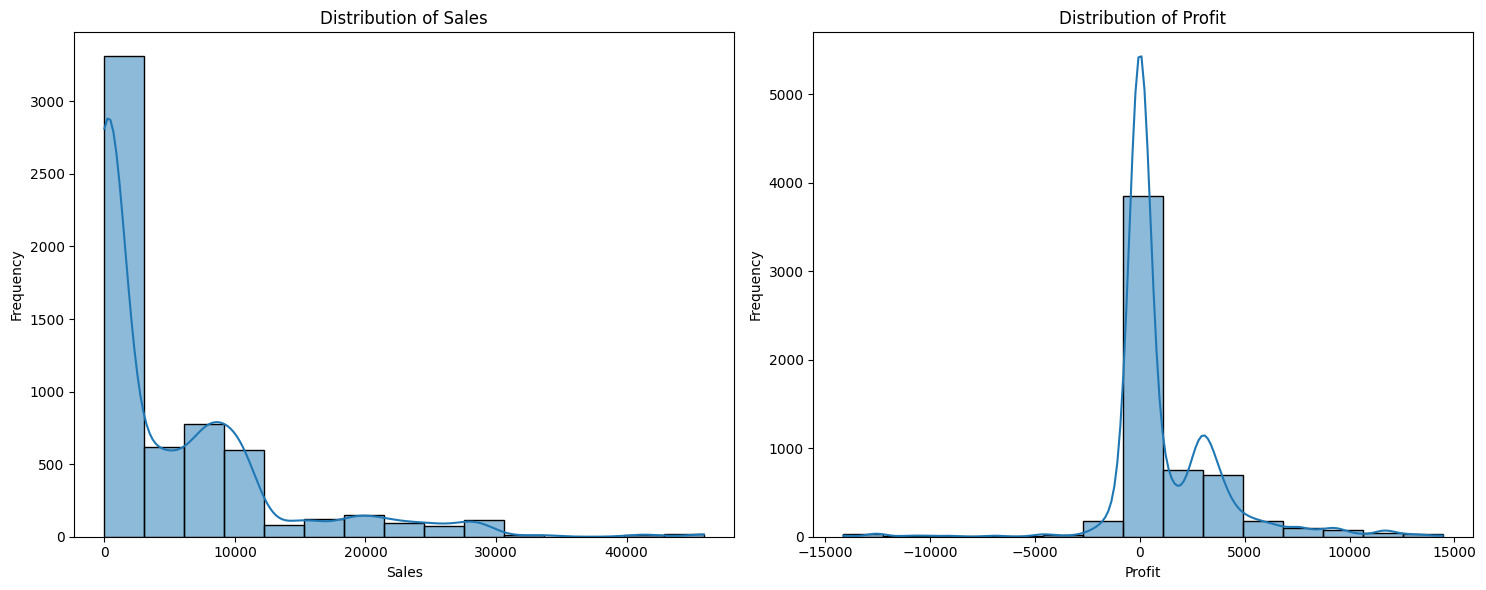


Sales Skewness: 2.0320
Sales Kurtosis: 4.8308

Profit Skewness: 0.7687
Profit Kurtosis: 7.6054

Based on Histograms and Skewness/Kurtosis:
Sales: The sales distribution is highly positively skewed (right-skewed) and leptokurtic (heavy tails and sharp peak). This suggests that most sales values are lower, but there are significant outliers with very high sales.
Profit: The profit distribution is also positively skewed (right-skewed) and leptokurtic. It shows a concentration of lower profit values, including negative profits (losses), and a long tail extending to higher profits. The high kurtosis indicates more extreme profit/loss values than a normal distribution.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Set up the plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for Sales
sns.histplot(df_prod['Sales'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Histogram for Profit
sns.histplot(df_prod['Profit'], bins=15, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Profit')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Calculate skewness and kurtosis
sales_skewness = skew(df_prod['Sales'])
sales_kurtosis = kurtosis(df_prod['Sales'])

profit_skewness = skew(df_prod['Profit'])
profit_kurtosis = kurtosis(df_prod['Profit'])

print(f"\nSales Skewness: {sales_skewness:.4f}")
print(f"Sales Kurtosis: {sales_kurtosis:.4f}")
print(f"\nProfit Skewness: {profit_skewness:.4f}")
print(f"Profit Kurtosis: {profit_kurtosis:.4f}")

print("\nBased on Histograms and Skewness/Kurtosis:")
print("Sales: The sales distribution is highly positively skewed (right-skewed) and leptokurtic (heavy tails and sharp peak). This suggests that most sales values are lower, but there are significant outliers with very high sales.")
print("Profit: The profit distribution is also positively skewed (right-skewed) and leptokurtic. It shows a concentration of lower profit values, including negative profits (losses), and a long tail extending to higher profits. The high kurtosis indicates more extreme profit/loss values than a normal distribution.")


### 4a.iii) Plot the plot the histogram for variable sales, profit based on customer segements,  based on these plots which segment provides more sales, profit and less sales, profit (assume bins  = 15) 4 marks



Histograms for Sales and Profit based on Customer Segments (2 Rows, 3 Columns):


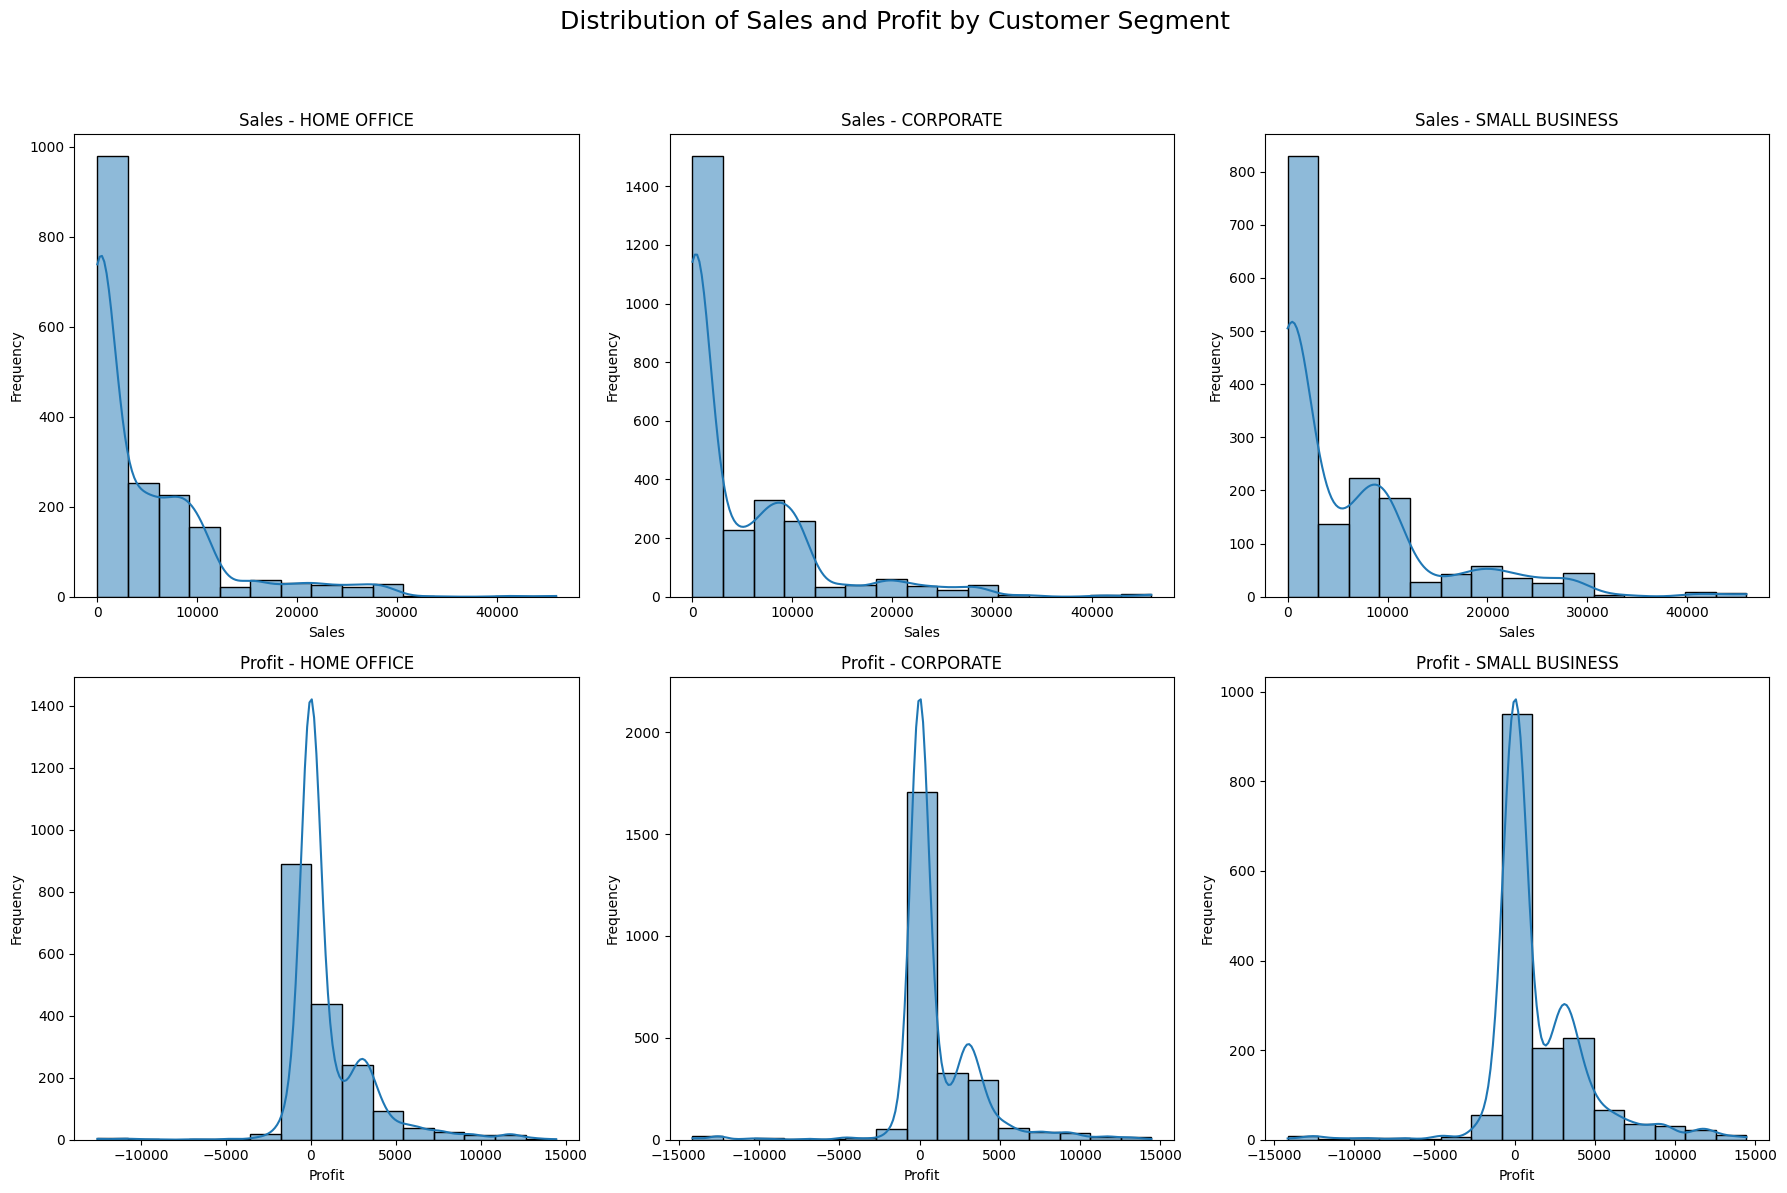

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique customer segments
customer_segments = df_prod['Customer_Segment'].unique()

print("Histograms for Sales and Profit based on Customer Segments (2 Rows, 3 Columns):")

# Create a single figure with 2 rows and 3 columns for all segments
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # 2 rows for Sales/Profit, 3 columns for segments
fig.suptitle('Distribution of Sales and Profit by Customer Segment', fontsize=18, y=1.02)

# Flatten axes for easier iteration if needed, but direct indexing is clear here

# Plotting histograms for Sales and Profit by Customer Segment
for i, segment in enumerate(customer_segments):
    segment_df = df_prod[df_prod['Customer_Segment'] == segment]

    # Sales Histograms (Row 0)
    sns.histplot(segment_df['Sales'], bins=15, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Sales - {segment}')
    axes[0, i].set_xlabel('Sales')
    axes[0, i].set_ylabel('Frequency')

    # Profit Histograms (Row 1)
    sns.histplot(segment_df['Profit'], bins=15, kde=True, ax=axes[1, i])
    axes[1, i].set_title(f'Profit - {segment}')
    axes[1, i].set_xlabel('Profit')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust rect to prevent suptitle overlap
plt.show()


In [61]:

# Analyze sales and profit by segment
print("\nAnalysis of Sales and Profit by Customer Segment:")

sales_by_segment = df_prod.groupby('Customer_Segment')['Sales'].mean().sort_values(ascending=False)
profit_by_segment = df_prod.groupby('Customer_Segment')['Profit'].mean().sort_values(ascending=False)

print("\nAverage Sales by Segment:")
print(sales_by_segment)

print("\nAverage Profit by Segment:")
print(profit_by_segment)

print("\nConclusion based on average values and histograms:")
print(f"- Segment with highest average Sales: {sales_by_segment.index[0]} (Avg Sales: {sales_by_segment.iloc[0]:.2f})")
print(f"- Segment with lowest average Sales: {sales_by_segment.index[-1]} (Avg Sales: {sales_by_segment.iloc[-1]:.2f})")
print(f"- Segment with highest average Profit: {profit_by_segment.index[0]} (Avg Profit: {profit_by_segment.iloc[0]:.2f})")
print(f"- Segment with lowest average Profit: {profit_by_segment.index[-1]} (Avg Profit: {profit_by_segment.iloc[-1]:.2f})")

print("\nObservation from Histograms:")
print(""" The histograms for each segment visually confirm the skewness observed in the overall sales and profit distributions.
The shapes of the distributions (e.g., presence of outliers, concentration of values) can vary between segments, reflecting their unique purchasing behaviors and profit margins. For instance, a segment with higher average sales/profit might also exhibit a wider spread or more high-value outliers in its histogram.""")


Analysis of Sales and Profit by Customer Segment:

Average Sales by Segment:
Customer_Segment
SMALL BUSINESS    6406.755575
CORPORATE         4866.284921
HOME OFFICE       4811.699036
Name: Sales, dtype: float64

Average Profit by Segment:
Customer_Segment
SMALL BUSINESS    1449.373122
HOME OFFICE       1049.893679
CORPORATE         1026.633175
Name: Profit, dtype: float64

Conclusion based on average values and histograms:
- Segment with highest average Sales: SMALL BUSINESS (Avg Sales: 6406.76)
- Segment with lowest average Sales: HOME OFFICE (Avg Sales: 4811.70)
- Segment with highest average Profit: SMALL BUSINESS (Avg Profit: 1449.37)
- Segment with lowest average Profit: CORPORATE (Avg Profit: 1026.63)

Observation from Histograms:
 The histograms for each segment visually confirm the skewness observed in the overall sales and profit distributions.
The shapes of the distributions (e.g., presence of outliers, concentration of values) can vary between segments, reflecting their un

### 4a.iv) Draw a scatter plot for all of the variables, what is your observation and conclusion for the relationship between sales and  the other numeric variables 4 marks


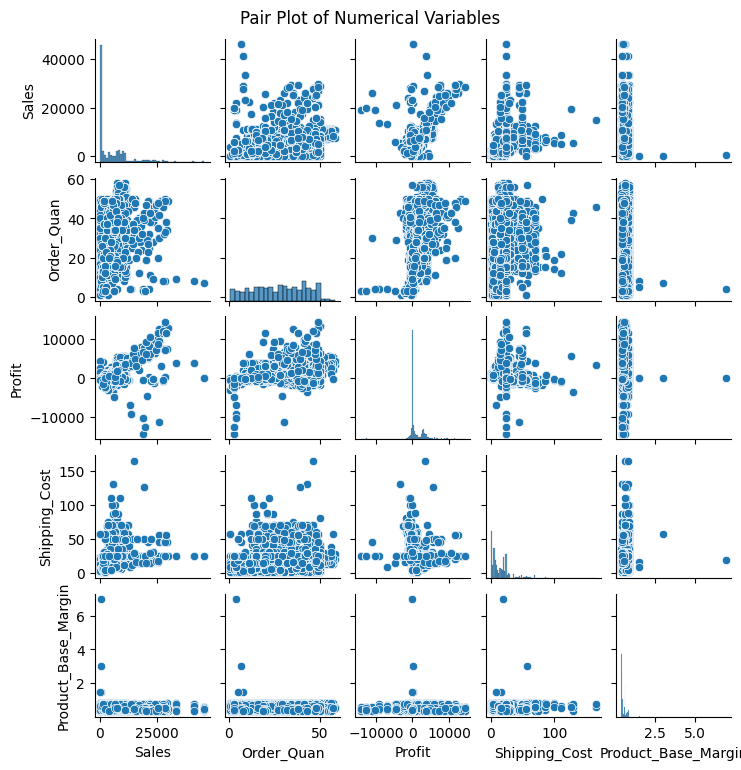

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for scatter plot
numerical_df_prod = df_prod.select_dtypes(include=['number'])

# Create a pair plot to visualize relationships between all numerical variables
sns.pairplot(numerical_df_prod, height=1.5) # Decreased height to reduce overall size
plt.suptitle('Pair Plot of Numerical Variables', y=1.02) # Add a title to the pair plot
plt.show()


In [63]:

print("\nObservation and Conclusion for the relationship between Sales and other numerical variables:")
print("Based on the scatter plots and the correlation analysis from 4a.i:")
print("- **Sales vs. Profit:** The scatter plot for Sales and Profit shows a clear positive linear relationship. As Sales increase, Profit generally increases. This is consistent with the high positive correlation (0.5857) observed earlier, indicating that higher sales strongly contribute to higher profits.")
print("- **Sales vs. Shipping_Cost:** The scatter plot between Sales and Shipping_Cost also suggests a positive relationship, though with more spread. Larger sales often involve higher shipping costs, which makes sense for physical goods. This aligns with the moderate positive correlation (0.4559).")
print("- **Sales vs. Product_Base_Margin:** The scatter plot for Sales and Product_Base_Margin appears to have a very weak or no discernible linear pattern. This is consistent with the low correlation (0.1806), suggesting that the base margin of a product does not strongly dictate its sales volume.")
print("- **Sales vs. Order_Quan:** The scatter plot for Sales and Order_Quan also shows a weak positive relationship, if any. While more units sold (Order Quantity) might contribute to higher sales, it's not a strong linear driver compared to Profit or Shipping_Cost, which is reflected in its low correlation (0.1517). Outliers in sales values are distributed across various order quantities.")
print("\nIn summary, Profit has the strongest positive linear relationship with Sales, followed by Shipping_Cost. Product_Base_Margin and Order_Quan have very weak positive relationships with Sales.")



Observation and Conclusion for the relationship between Sales and other numerical variables:
Based on the scatter plots and the correlation analysis from 4a.i:
- **Sales vs. Profit:** The scatter plot for Sales and Profit shows a clear positive linear relationship. As Sales increase, Profit generally increases. This is consistent with the high positive correlation (0.5857) observed earlier, indicating that higher sales strongly contribute to higher profits.
- **Sales vs. Shipping_Cost:** The scatter plot between Sales and Shipping_Cost also suggests a positive relationship, though with more spread. Larger sales often involve higher shipping costs, which makes sense for physical goods. This aligns with the moderate positive correlation (0.4559).
- **Sales vs. Product_Base_Margin:** The scatter plot for Sales and Product_Base_Margin appears to have a very weak or no discernible linear pattern. This is consistent with the low correlation (0.1806), suggesting that the base margin of a pro

### 4b. Consider the purchases.csv file and answer the following questions

### 4b.i)Draw a boxplot for sales based on customer segments, what do you observe in terms of outliers, and sales difference for various segments. 3


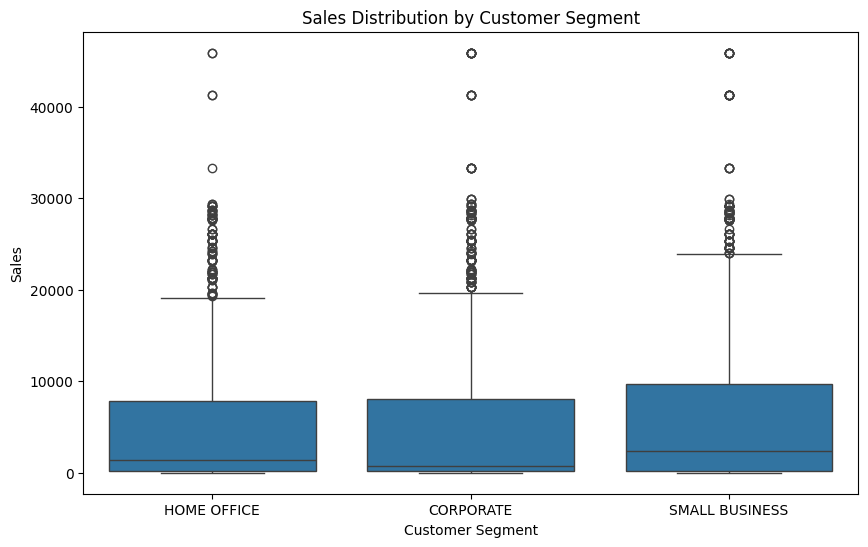


Observations from the Boxplot of Sales by Customer Segment:
- **Outliers:** All three customer segments (Home Office, Corporate, Small Business) show a significant number of outliers, particularly on the higher end of sales. This indicates that while most sales fall within a certain range, there are many individual sales transactions that are much higher than the typical sales for that segment.
- **Sales Differences:**
  - **Small Business** segment appears to have the highest median sales and also reaches the highest sales values, suggesting it's the top-performing segment in terms of overall sales figures and potential for high-value transactions.
  - **Corporate** and **Home Office** segments have similar median sales values, which are generally lower than that of Small Business. Their interquartile ranges (the box itself) are also quite similar.
  - While Home Office might have a slightly lower median than Corporate, their overall distributions, including the presence and magnitud

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draw a boxplot for sales based on customer segments
plt.figure(figsize=(10, 6))
sns.boxplot(x='Customer_Segment', y='Sales', data=df_prod)
plt.title('Sales Distribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')
plt.show()

print("\nObservations from the Boxplot of Sales by Customer Segment:")
print("- **Outliers:** All three customer segments (Home Office, Corporate, Small Business) show a significant number of outliers, particularly on the higher end of sales. This indicates that while most sales fall within a certain range, there are many individual sales transactions that are much higher than the typical sales for that segment.")
print("- **Sales Differences:**")
print("  - **Small Business** segment appears to have the highest median sales and also reaches the highest sales values, suggesting it's the top-performing segment in terms of overall sales figures and potential for high-value transactions.")
print("  - **Corporate** and **Home Office** segments have similar median sales values, which are generally lower than that of Small Business. Their interquartile ranges (the box itself) are also quite similar.")
print("  - While Home Office might have a slightly lower median than Corporate, their overall distributions, including the presence and magnitude of outliers, are comparable and generally lower than Small Business.")
print("In conclusion, the 'Small Business' segment stands out with higher overall sales and more frequent high-value sales, while 'Corporate' and 'Home Office' segments show similar, albeit lower, sales performance with numerous high-value outliers present across all segments.")

### 4b.ii)Conduct a hypothesis to see whether there is a difference in terms of sales for customer segment of home business and corporate. What do you conclude 4 - marks

In [65]:
# 4b.ii) Conduct a hypothesis to see whether there is a difference in terms of sales for customer segment of home business and corporate.

# i) State the null hypothesis and the alternate hypothesis.
print("i) Hypothesis:")
print("Null Hypothesis (H0): There is no difference in mean sales between Home Office and Corporate segments (μ_home_office = μ_corporate).")
print("Alternate Hypothesis (H1): There is a significant difference in mean sales between Home Office and Corporate segments (μ_home_office ≠ μ_corporate).")

# ii) Extract sales data for each segment
sales_home_office = df_prod[df_prod['Customer_Segment'] == 'HOME OFFICE']['Sales']
sales_corporate = df_prod[df_prod['Customer_Segment'] == 'CORPORATE']['Sales']

# iii) Perform independent samples t-test (two-tailed)
# Assuming equal variances for now, as not specified otherwise. We can check this assumption if needed.
t_statistic, p_value = stats.ttest_ind(sales_home_office, sales_corporate, equal_var=True)

print(f"\niii) Test Statistics and P-value:")
print(f"Test Statistic (t): {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# iv) Conclusion at the 0.05 significance level
alpha = 0.05
print(f"\niv) Conclusion at significance level {alpha}:")

if p_value < alpha:
    print("Since the P-value is less than the significance level (0.05),")
    print("we reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is a statistically significant difference in mean sales between the Home Office and Corporate customer segments.")
else:
    print("Since the P-value is greater than or equal to the significance level (0.05),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is no statistically significant difference in mean sales between the Home Office and Corporate customer segments.")

print(f"\nMean Sales - Home Office: {sales_home_office.mean():.2f}")
print(f"Mean Sales - Corporate: {sales_corporate.mean():.2f}")

i) Hypothesis:
Null Hypothesis (H0): There is no difference in mean sales between Home Office and Corporate segments (μ_home_office = μ_corporate).
Alternate Hypothesis (H1): There is a significant difference in mean sales between Home Office and Corporate segments (μ_home_office ≠ μ_corporate).

iii) Test Statistics and P-value:
Test Statistic (t): -0.2525
P-value: 0.8006

iv) Conclusion at significance level 0.05:
Since the P-value is greater than or equal to the significance level (0.05),
we fail to reject the null hypothesis.
Conclusion: At the 0.05 significance level, there is no statistically significant difference in mean sales between the Home Office and Corporate customer segments.

Mean Sales - Home Office: 4811.70
Mean Sales - Corporate: 4866.28


### 4b.iii)Conduct an hypothesis to prove whether the sales from small business segment is mote than corporate, do you agree or not. 4 marks

In [66]:
# 4b.iii) Conduct an hypothesis to prove whether the sales from small business segment is more than corporate, do you agree or not.

# i) State the null hypothesis and the alternate hypothesis.
print("i) Hypothesis:")
print("Null Hypothesis (H0): The mean sales of Small Business are less than or equal to the mean sales of Corporate (μ_small_business <= μ_corporate).")
print("Alternate Hypothesis (H1): The mean sales of Small Business are greater than the mean sales of Corporate (μ_small_business > μ_corporate).")

# ii) Extract sales data for each segment
sales_small_business = df_prod[df_prod['Customer_Segment'] == 'SMALL BUSINESS']['Sales']
sales_corporate = df_prod[df_prod['Customer_Segment'] == 'CORPORATE']['Sales']

# iii) Perform independent samples t-test (one-tailed, 'greater')
# Assuming equal variances as per previous tests, but it's good practice to verify.
t_statistic, p_value = stats.ttest_ind(sales_small_business, sales_corporate, equal_var=True, alternative='greater')

print(f"\niii) Test Statistics and P-value:")
print(f"Test Statistic (t): {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# iv) Conclusion at the 0.05 significance level
alpha = 0.05
print(f"\niv) Conclusion at significance level {alpha}:")

if p_value < alpha:
    print("Since the P-value is less than the significance level (0.05),")
    print("we reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is statistically significant evidence to conclude that the mean sales for the Small Business segment are greater than for the Corporate segment.")
    print("Therefore, I agree with the statement that sales from the Small Business segment are more than Corporate.")
else:
    print("Since the P-value is greater than or equal to the significance level (0.05),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: At the 0.05 significance level, there is no statistically significant evidence to conclude that the mean sales for the Small Business segment are greater than for the Corporate segment.")
    print("Therefore, I do not agree with the statement that sales from the Small Business segment are more than Corporate.")

print(f"\nMean Sales - Small Business: {sales_small_business.mean():.2f}")
print(f"Mean Sales - Corporate: {sales_corporate.mean():.2f}")

i) Hypothesis:
Null Hypothesis (H0): The mean sales of Small Business are less than or equal to the mean sales of Corporate (μ_small_business <= μ_corporate).
Alternate Hypothesis (H1): The mean sales of Small Business are greater than the mean sales of Corporate (μ_small_business > μ_corporate).

iii) Test Statistics and P-value:
Test Statistic (t): 6.3126
P-value: 0.0000

iv) Conclusion at significance level 0.05:
Since the P-value is less than the significance level (0.05),
we reject the null hypothesis.
Conclusion: At the 0.05 significance level, there is statistically significant evidence to conclude that the mean sales for the Small Business segment are greater than for the Corporate segment.
Therefore, I agree with the statement that sales from the Small Business segment are more than Corporate.

Mean Sales - Small Business: 6406.76
Mean Sales - Corporate: 4866.28




### 4b.iv)Conduct an ANOVA to check whether there is sales difference for products of the following type Paper, Telephones and Communications, Binder and Binder Accessories and Computer Perephirals. 4 marks






In [67]:
# 4b.iv) Conduct an ANOVA to check whether there is sales difference for products of the following type Paper, Telephones and Communications, Binder and Binder Accessories and Computer Peripherals.

# i) State the null hypothesis and the alternate hypothesis.
print("i) Hypothesis:")
print("Null Hypothesis (H0): There is no significant difference in mean sales among the selected product types (μ_paper = μ_telephones = μ_binder = μ_computer).")
print("Alternate Hypothesis (H1): At least one product type has a significantly different mean sales.")

# ii) Extract sales data for each specified product type
sales_paper = df_prod[df_prod['Products'] == 'PAPER']['Sales']
sales_telephones = df_prod[df_prod['Products'] == 'TELEPHONES AND COMMUNICATION']['Sales']
sales_binder = df_prod[df_prod['Products'] == 'BINDERS AND BINDER ACCESSORIES']['Sales']
sales_computer = df_prod[df_prod['Products'] == 'COMPUTER PERIPHERALS']['Sales']

# Ensure all groups have data
if sales_paper.empty or sales_telephones.empty or sales_binder.empty or sales_computer.empty:
    print("\nError: One or more product types have no sales data. Please check product names.")
else:
    # iii) Perform One-Way ANOVA
    f_statistic, p_value = stats.f_oneway(sales_paper, sales_telephones, sales_binder, sales_computer)

    print(f"\niii) Test Statistics and P-value:")
    print(f"F-statistic: {f_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    # iv) Conclusion at the 0.05 significance level
    alpha = 0.05
    print(f"\niv) Conclusion at significance level {alpha}:")

    if p_value < alpha:
        print("Since the P-value is less than the significance level (0.05),")
        print("we reject the null hypothesis.")
        print("Conclusion: At the 0.05 significance level, there is a statistically significant difference in mean sales among the selected product types.")
    else:
        print("Since the P-value is greater than or equal to the significance level (0.05),")
        print("we fail to reject the null hypothesis.")
        print("Conclusion: At the 0.05 significance level, there is no statistically significant difference in mean sales among the selected product types.")

    print("\nMean Sales for each product type:")
    print(f"Paper: {sales_paper.mean():.2f}")
    print(f"Telephones and Communications: {sales_telephones.mean():.2f}")
    print(f"Binder and Binder Accessories: {sales_binder.mean():.2f}")
    print(f"Computer Peripherals: {sales_computer.mean():.2f}")

i) Hypothesis:
Null Hypothesis (H0): There is no significant difference in mean sales among the selected product types (μ_paper = μ_telephones = μ_binder = μ_computer).
Alternate Hypothesis (H1): At least one product type has a significantly different mean sales.

iii) Test Statistics and P-value:
F-statistic: 2103.8991
P-value: 0.0000

iv) Conclusion at significance level 0.05:
Since the P-value is less than the significance level (0.05),
we reject the null hypothesis.
Conclusion: At the 0.05 significance level, there is a statistically significant difference in mean sales among the selected product types.

Mean Sales for each product type:
Paper: 766.00
Telephones and Communications: 9081.59
Binder and Binder Accessories: 842.01
Computer Peripherals: 13864.19
